In [7]:
import tensorflow as tf
import keras
import gensim
import sklearn
import nltk
import konlpy
import pandas as pd

In [8]:
tf.__version__, keras.__version__, gensim.__version__, sklearn.__version__, nltk.__version__, konlpy.__version__, pd.__version__

('2.15.0', '2.15.0', '4.3.2', '1.2.2', '3.8.1', '0.6.0', '1.5.3')

## 시리즈(Series)  
Series 클래스는 1차원 배열의 값(values)에 각 값에 대응되는 인덱스(index)를 부여할 수 있는 구조

In [9]:
sr = pd.Series([17000, 18000, 1000, 5000],
               index=["피자", "치킨", "콜라", "맥주"])
print(sr)

피자    17000
치킨    18000
콜라     1000
맥주     5000
dtype: int64


In [10]:
sr.values, sr.index

(array([17000, 18000,  1000,  5000]),
 Index(['피자', '치킨', '콜라', '맥주'], dtype='object'))

## 데이터프레임(DataFrame)  
DataFrame은 2차원 리스트를 매개변수로 전달합니다.  
행(index)과 열(column)을 가지는 자료구조  

---
Series: index와 values로 구성  
DataFrame: columns, index, values로 구성

In [11]:
values = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]
index = ['one', 'two', 'three']
columns = ['A', 'B', 'C']

df = pd.DataFrame(values, index=index, columns=columns)
print(df)

       A  B  C
one    1  2  3
two    4  5  6
three  7  8  9


In [12]:
df.index, df.columns, df.values

(Index(['one', 'two', 'three'], dtype='object'),
 Index(['A', 'B', 'C'], dtype='object'),
 array([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]]))

DataFrame은 List, Series, dict, Numpy의 ndarrays, 다른 DataFrame으로부터 생성  

---
### 리스트(List)

In [13]:
# List로 생성하기
data = [
    ['1000', 'Steve', 90.72],
    ['1001', 'James', 78.09],
    ['1002', 'Doyeon', 98.43],
    ['1003', 'Jane', 64.19],
    ['1004', 'Pilwoong', 81.30],
    ['1005', 'Tony', 99.14],
]

df = pd.DataFrame(data)
print(df)

      0         1      2
0  1000     Steve  90.72
1  1001     James  78.09
2  1002    Doyeon  98.43
3  1003      Jane  64.19
4  1004  Pilwoong  81.30
5  1005      Tony  99.14


In [14]:
df.index, df.columns, df.values

(RangeIndex(start=0, stop=6, step=1),
 RangeIndex(start=0, stop=3, step=1),
 array([['1000', 'Steve', 90.72],
        ['1001', 'James', 78.09],
        ['1002', 'Doyeon', 98.43],
        ['1003', 'Jane', 64.19],
        ['1004', 'Pilwoong', 81.3],
        ['1005', 'Tony', 99.14]], dtype=object))

In [15]:
# columns 이름 지정
df = pd.DataFrame(data, columns=['학번', '이름', '점수'])
print(df)

     학번        이름     점수
0  1000     Steve  90.72
1  1001     James  78.09
2  1002    Doyeon  98.43
3  1003      Jane  64.19
4  1004  Pilwoong  81.30
5  1005      Tony  99.14


In [16]:
df.columns

Index(['학번', '이름', '점수'], dtype='object')

### 딕셔너리(dictionary)

In [17]:
# dictionary로 생성하기
data = {
    '학번' : ['1000', '1001', '1002', '1003', '1004', '1005'],
    '이름' : [ 'Steve', 'James', 'Doyeon', 'Jane', 'Pilwoong', 'Tony'],
    '점수': [90.72, 78.09, 98.43, 64.19, 81.30, 99.14]
    }

df = pd.DataFrame(data)
print(df)

     학번        이름     점수
0  1000     Steve  90.72
1  1001     James  78.09
2  1002    Doyeon  98.43
3  1003      Jane  64.19
4  1004  Pilwoong  81.30
5  1005      Tony  99.14


In [18]:
df.index, df.columns, df.values

(RangeIndex(start=0, stop=6, step=1),
 Index(['학번', '이름', '점수'], dtype='object'),
 array([['1000', 'Steve', 90.72],
        ['1001', 'James', 78.09],
        ['1002', 'Doyeon', 98.43],
        ['1003', 'Jane', 64.19],
        ['1004', 'Pilwoong', 81.3],
        ['1005', 'Tony', 99.14]], dtype=object))

In [19]:
# DataFrame 조회하기
print(df.head(3))
print(df.tail(3))
print(df['학번'])

     학번      이름     점수
0  1000   Steve  90.72
1  1001   James  78.09
2  1002  Doyeon  98.43
     학번        이름     점수
3  1003      Jane  64.19
4  1004  Pilwoong  81.30
5  1005      Tony  99.14
0    1000
1    1001
2    1002
3    1003
4    1004
5    1005
Name: 학번, dtype: object


Pandas는 CSV, txt, Excel, SQL, HTML, JSON 등을 읽고 DataFrame을 생성

In [20]:
df = pd.read_csv('example.csv')
print(df)

   student id      name  score
0        1000     Steve  90.72
1        1001     James  78.09
2        1002    Doyeon  98.43
3        1003      Jane  64.19
4        1004  Pilwoong  81.30
5        1005      Tony  99.14


In [21]:
df.index, df.columns, df.values

(RangeIndex(start=0, stop=6, step=1),
 Index(['student id', 'name', 'score'], dtype='object'),
 array([[1000, 'Steve', 90.72],
        [1001, 'James', 78.09],
        [1002, 'Doyeon', 98.43],
        [1003, 'Jane', 64.19],
        [1004, 'Pilwoong', 81.3],
        [1005, 'Tony', 99.14]], dtype=object))

## 넘파이(Numpy)  
Numpy는 수치 데이터를 다루는 파이썬 패키지  
다차원 행렬 자료구조 ndarray를 통해 벡터/행렬을 사용하는 선형 대수에서 사용  
편의성과 빠른 속도가 장점


In [22]:
import numpy as np
np.__version__

'1.23.5'

### 다차원 배열(ndarray)

 np.array()는 List, Tuple, Array로 ndarray를 생성

---
 List를 가지고 1차원 배열을 생성  

In [23]:
# 1차원 배열
vec = np.array([1, 2, 3, 4, 5])
print(vec)

[1 2 3 4 5]


In [24]:
# 2차원 배열
mat = np.array([[10, 20, 30], [ 60, 70, 80]])
print(mat)

[[10 20 30]
 [60 70 80]]


In [25]:
type(vec), type(mat)

(numpy.ndarray, numpy.ndarray)

Numpy 배열에는 축의 개수(ndim)와 크기(shape)라는 개념이 존재

In [26]:
vec.ndim, vec.shape # 축의 개수, 크기 출력

(1, (5,))

In [27]:
mat.ndim, mat.shape

(2, (2, 3))

ndarray 초기화  
ndarray를 만드는 다양한 다른 방법  

---
np.zeros()는 배열의 모든 원소에 0을 삽입

In [30]:
# 모든 값이 0인 2x3 배열 생성
zero_mat = np.zeros((2,3))
print(zero_mat)

[[0. 0. 0.]
 [0. 0. 0.]]


In [31]:
# 모든 값이 1인 2x3 배열 생성
one_mat = np.ones((2,3))
print(one_mat)

[[1. 1. 1.]
 [1. 1. 1.]]


In [32]:
# 모든 값이 특정 상수인 배열 생성
same_value_mat = np.full((2,2), 7)
print(same_value_mat)

[[7 7]
 [7 7]]


In [33]:
# 대각선 값이 1이고 나머지 값이 0인 2차원 배열을 생성
eye_mat = np.eye(3)
print(eye_mat)

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [34]:
# 임의의 값으로 채워진 배열 생성
random_mat = np.random.random((2,2)) # 임의의 값으로 채워진 배열 생성
print(random_mat)

[[0.69842078 0.34055859]
 [0.029223   0.31278672]]


np.arange(n)은 0부터 n-1까지의 값을 가지는 배열을 생성

In [35]:
# 0부터 9까지
range_vec = np.arange(10)
print(range_vec)

[0 1 2 3 4 5 6 7 8 9]


np.arange(i, j, k)는 i부터 j-1까지 k씩 증가하는 배열을 생성

In [36]:
# 1부터 9까지 +2씩 적용되는 범위
n = 2
range_n_step_vec = np.arange(1, 10, n)
print(range_n_step_vec)

[1 3 5 7 9]


np.reshape()은 내부 데이터는 변경하지 않으면서 배열의 구조를 변경  



In [37]:
reshape_mat = np.array(np.arange(30)).reshape((5,6))
print(reshape_mat) # (30,) -> (5,6)

[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]
 [12 13 14 15 16 17]
 [18 19 20 21 22 23]
 [24 25 26 27 28 29]]


Numpy 슬라이싱  
ndarray를 통해 만든 다차원 배열은 슬라이싱(slicing) 기능을 지원  
slicing 기능을 사용하여 특정 행이나 열들의 원소들을 접근

In [38]:
mat = np.array([[1, 2, 3], [4, 5, 6]])
print(mat)

[[1 2 3]
 [4 5 6]]


In [39]:
# 첫번째 행 출력
slicing_mat = mat[0, :]
print(slicing_mat)

[1 2 3]


In [40]:
# 두번째 열 출력
slicing_mat = mat[:, 1]
print(slicing_mat)

[2 5]


Numpy 정수 인덱싱(integer indexing)

indexing은 원하는 위치의 원소들을 추출

In [41]:
mat = np.array([[1, 2], [4, 5], [7, 8]])
print(mat)

[[1 2]
 [4 5]
 [7 8]]


In [42]:
# 1행 0열의 원소 (두번째 행 첫번째 열)
print(mat[1, 0]) # [[1],[0]]

4


In [43]:
# mat[[2행, 1행],[0열, 1열]]
# 각 행과 열의 쌍을 매칭하면 2행 0열, 1행 1열의 두 개의 원소.
indexing_mat = mat[[2, 1],[0, 1]]
print(indexing_mat)

[7 5]


Numpy 연산  

Numpy를 사용하면 배열간 연산을 수행  
+, -, *, / 또는 np.add(), np.subtract(), np.multiply(), np.divide() 사용

In [44]:
x = np.array([1,2,3])
y = np.array([4,5,6])

In [45]:
# result = np.add(x, y)와 동일
result = x + y
print(result)

[5 7 9]


In [46]:
# result = np.subtract(x, y)와 동일
result = x - y
print(result)

[-3 -3 -3]


In [47]:
# result = np.multiply(result, x)와 동일
result = result * x
print(result)

[-3 -6 -9]


In [48]:
# result = np.divide(result, x)와 동일
result = result / x
print(result)

[-3. -3. -3.]


*은 요소별 곱

Numpy에서 벡터와 행렬곱 또는 행렬곱을 위해서는 dot()을 사용

In [49]:
mat1 = np.array([[1,2],[3,4]])
mat2 = np.array([[5,6],[7,8]])
mat1, mat2

(array([[1, 2],
        [3, 4]]),
 array([[5, 6],
        [7, 8]]))

In [50]:
mat3 = np.dot(mat1, mat2)
print(mat3)

# 1*5 + 2*7 = 19, 1*6 + 2*8 = 22
# 3*5 + 4*7 = 43, 3*6 + 4*8 = 50

[[19 22]
 [43 50]]


In [51]:
mat1 * mat2
# 1*5 = 5, 2*6 = 12
# 3*7 = 21, 4*8 = 32

array([[ 5, 12],
       [21, 32]])

## 맷플롯립(Matplotlib)  

Matplotlib은 데이터를 chart/plot으로 시각화하는 패키지  

데이터 분석 전에 데이터 이해를 위한 시각화    
데이터 분석 후에 결과를 시각화하기 위해 사용

In [52]:
import matplotlib as mpl
mpl.__version__

'3.7.1'

In [53]:
import matplotlib.pyplot as plt

라인 플롯 그리기  

plot()은 라인 플롯을 그리는 기능을 수행  
plot()에 x축과 y축의 값을 기재  
그림을 표시하는 show()를 통해서 시각화  
그래프에는 title('제목')을 사용하여 제목을 지정

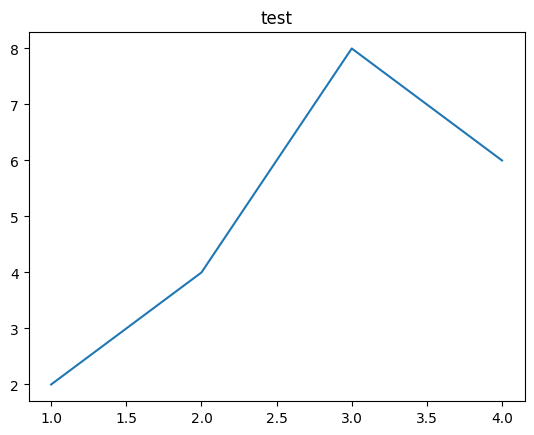

In [54]:
plt.title('test')
plt.plot([1,2,3,4],[2,4,8,6])
plt.show()

축 레이블 삽입하기  

x축과 y축 각각에 축이름을 삽입  
xlabel('넣고 싶은 축이름')과 ylabel('넣고 싶은 축이름')을 사용

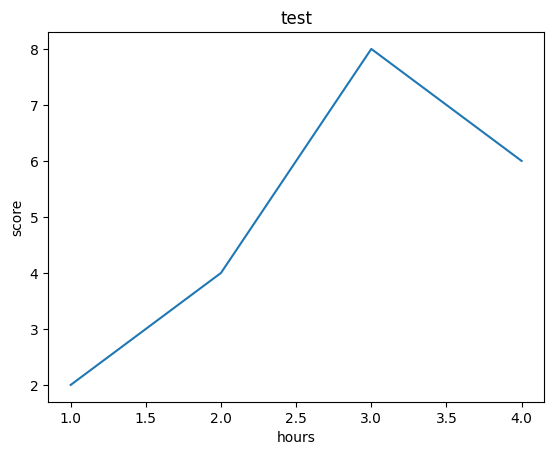

In [55]:
plt.title('test')
plt.plot([1,2,3,4],[2,4,8,6])
plt.xlabel('hours')
plt.ylabel('score')
plt.show()

라인 추가와 범례 삽입하기  

다수의 plot()을 하나의 그래프에 나타낼 수 있습니다.  

여러 개의 라인 플롯을 동시에 사용할 경우,  
각 선이 어떤 데이터를 나타내는지를 보여주기 위해 범례(legend)를 사용

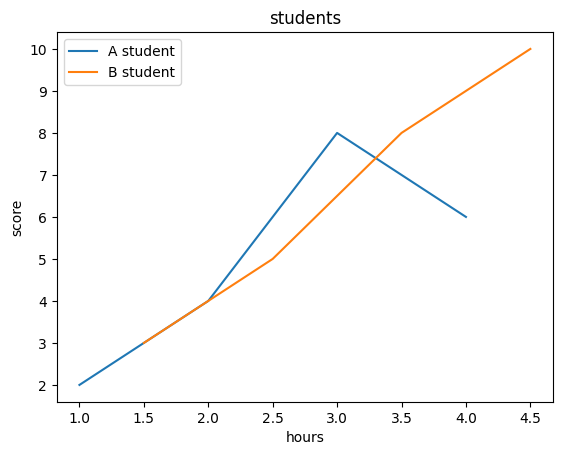

In [56]:
plt.title('students')
plt.plot([1,2,3,4],[2,4,8,6])
plt.plot([1.5,2.5,3.5,4.5],[3,5,8,10]) # 라인 새로 추가
plt.xlabel('hours')
plt.ylabel('score')
plt.legend(['A student', 'B student']) # 범례 삽입
plt.show()

## 판다스 프로파일링(Pandas-Profiling)  

좋은 머신 러닝 결과를 얻기 위해서는 데이터의 성격을 파악해야 한다.  
EDA를 통해 데이터 내 값의 분포, 변수 간의 관계, Null(missing values) 존재 유무 등을 파악한다.  

---
판다스 프로파일링(pandas-profiling)  
방대한 양의 데이터를 가진 데이터프레임을 탐색하는 패키지

In [1]:
import pandas as pd
import ydata_profiling

In [2]:
data = pd.read_csv('spam.csv',encoding='latin1')

In [3]:
data[:5]

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


v1열: 해당 메일이 스팸인지 아닌지를 나타내는 레이블
- ham: 정상 메일, spam: 스팸 메일  

v2열: 메일의 본문

---
리포트 생성하기

In [4]:
pr=data.profile_report() # 프로파일링 결과 리포트를 pr에 저장

In [5]:
# pr.to_file('./pr_report.html') # pr_report.html 파일로 저장

In [6]:
pr # pr에 저장했던 리포트 출력

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

### 개요(Overview)

Overview는 데이터의 전체적인 개요  
데이터의 크기, 변수의 수, 결측값 비율, 데이터의 종류  

---
Dataset info

총 5,572개의 샘플(행), 5개의 열
총 5,572 X 5개의 셀이 존재 그 중 16,648개(59.8%)가 결측값  

Warnings

결측값들은 Unnamed라는 3개의 열에 존재  
3개의 열은 99% 이상 결측값을 갖고 있어 데이터에서 큰 의미를 갖지 못함  

v2열(메일 본문)은 총 5,169개의 중복되지 않은 값(distinct value)을 가짐  
총 샘플의 개수 5,572개 중 403개의 메일은 중복

### 변수(Variables)  

Variables는 모든 변수들에 대한 결측값, unique values의 개수 등의 통계치  
상위 5개의 값에 대해 바 그래프로 시각화한 결과를 제공  

Unnamed_2 열은 총 5,572개의 값 중에서 5,522개가 결측값  
결측값이 아닌 값은 총 50개  
그 중 중복을 제거한 유일한 값의 개수는 43개  

---
v1은 스팸 메일의 유무 (ham/spam), v2는 메일의 본문

- v1에서 유일한 값의 개수(distinct count)는 2개  
ham: 4,825개 / spam: 747개  
정상 메일 샘플이 훨씬 많음  

- v2의 경우, 중복을 제외하면 5,169개의 유일한 내용의 메일 본문  
중복이 가장 많은 메일은 Sorry, I'll call later라는 내용의 메일 (총 30개)  

v1과 v2는 결측값이 없으므로 전처리를 수행할 때,  
3개의 열(Unnamed)을 제거하면 별도의 결측값 전처리는 필요없음

### 상세사항 확인하기(Toggle details)


v1의 Toggle details

- 빈도값(common values)  
각 값의 분포를 바 그래프보다 상세하게 출력  
ham: 4,825개(86.6%) / spam: 747개(13.4%)

- 구성(composition)  
전체 값의 최대 길이, 최소 길이, 평균 길이와 값의 구성  
spam 길이: 4 (max length) / ham 길이: 3 (min length) / 평균 길이: 3.13406  
알파벳만으로 구성 -> Contains chars만 True (숫자, 공백, 특수 문자 등 없음)

v2의 Toggle details  
- 빈도값(common values)  
중복이 존재하는 상위 10개 메일의 내용

- 구성(composition)  
값의 최대 길이: 910 / 최소 길이: 2 / 평균 길이: 80.1188083  
글자, 숫자, 공백, 특수문자 등이 모두 포함 -> 모든 Contains은 True

수치형 데이터를 위한 상관계수(correlations), 결측값에 대한 히트맵(headmap), 수지도(dendrogram) 등의 기능 지원

## 머신 러닝 워크플로우(Machine Learning Workflow)

데이터를 수집하고 머신 러닝을 하는 과정 6가지  
수집 - 점검 및 탐색 - 전처리 및 정제 - 모델링 및 훈련 - 평가 - 배포


1) 수집(Acquisition)  
자연어 처리의 경우, 말뭉치 또는 코퍼스(corpus)  
코퍼스: 조사/연구 목적에 의해 특정 도메인으로부터 수집된 텍스트 집합  
> 텍스트 데이터  
파일 형식은 txt, csv, xml 등  
파일 출처는 음성 데이터, 웹 수집기, 영화 리뷰 등  

2) 점검 및 탐색(Inspection and exploration)  
데이터 구조, 노이즈 데이터, 머신 러닝 적용을 위한 데이터 정제 방법 등 파악  
> EDA 단계  
독립/종속 변수, 변수 유형, 데이터 타입 등 점검  
데이터 특징과 내재하는 구조적 관계를 알아내는 과정  
시각화와 간단한 통계 테스트를 진행  

3) 전처리 및 정제(Preprocessing and Cleaning)  
자연어 처리는 토큰화, 정제, 정규화, 불용어 제거 등의 단계를 포함  
빠르고 정확한 전처리를 위해서는 다양한 라이브러리에 대한 지식 필요  
전처리 과정에서 머신 러닝이 사용되기도 함

4) 모델링 및 훈련(Modeling and Training)  
머신 러닝에 대한 코드를 작성하는 단계  

머신 러닝 알고리즘을 선택하여 모델링  
전처리 된 데이터를 머신 러닝 알고리즘을 통해 기계에게 학습/훈련(training)  
훈련이 되었다면 기계는 우리가 원하는 태스크(task) 수행
- task: 기계 번역, 음성 인식, 텍스트 분류 등의 자연어 처리 작업

**주의: 모든 데이터를 기계에게 학습시켜서는 안 됨.**  
테스트용, 훈련용으로 구분 후, 훈련용만 사용   
학습 후, 테스트용 데이터를 통해 현재 성능 측정, 과적합(overfitting) 방지  
보통 훈련용, 검증용, 테스트용으로 구분  

> 검증용과 테스트용의 차이  
> - 검증용 데이터: 현재 모델의 성능을 판단  
훈련용 데이터로 얼마나 제대로 학습이 되었는지를 판단  
검증용 데이터를 사용하여 모델의 성능을 개선  

> - 테스트용 데이터: 모델의 최종 성능을 평가  
모델의 성능을 수치화하여 평가하기 위해 사용  

5) 평가(Evaluation)  
테스트용 데이터로 성능을 평가  
예측한 데이터가 테스트용 데이터의 실제 정답과 얼마나 가까운지 측정  

6) 배포(Deployment)  
성공적으로 훈련이 되면 완성된 모델을 배포되는 단계  
모델을 업데이트 해야하는 상황이 오면 수집 단계로 반복